# **Data Load**

In [1]:
import zipfile
import os

zip_path = "/content/classification_task.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/dataset


In [2]:
for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/classification_task
/content/dataset/classification_task/train
/content/dataset/classification_task/train/pituitary
/content/dataset/classification_task/train/meningioma
/content/dataset/classification_task/train/glioma
/content/dataset/classification_task/train/no_tumor
/content/dataset/classification_task/test
/content/dataset/classification_task/test/pituitary
/content/dataset/classification_task/test/meningioma
/content/dataset/classification_task/test/glioma
/content/dataset/classification_task/test/no_tumor


# **Import all libraries**

In [9]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing.image import load_img

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
train_dir = "/content/dataset/classification_task/train"
test_dir = "/content/dataset/classification_task/test"

## **Image Visuals**

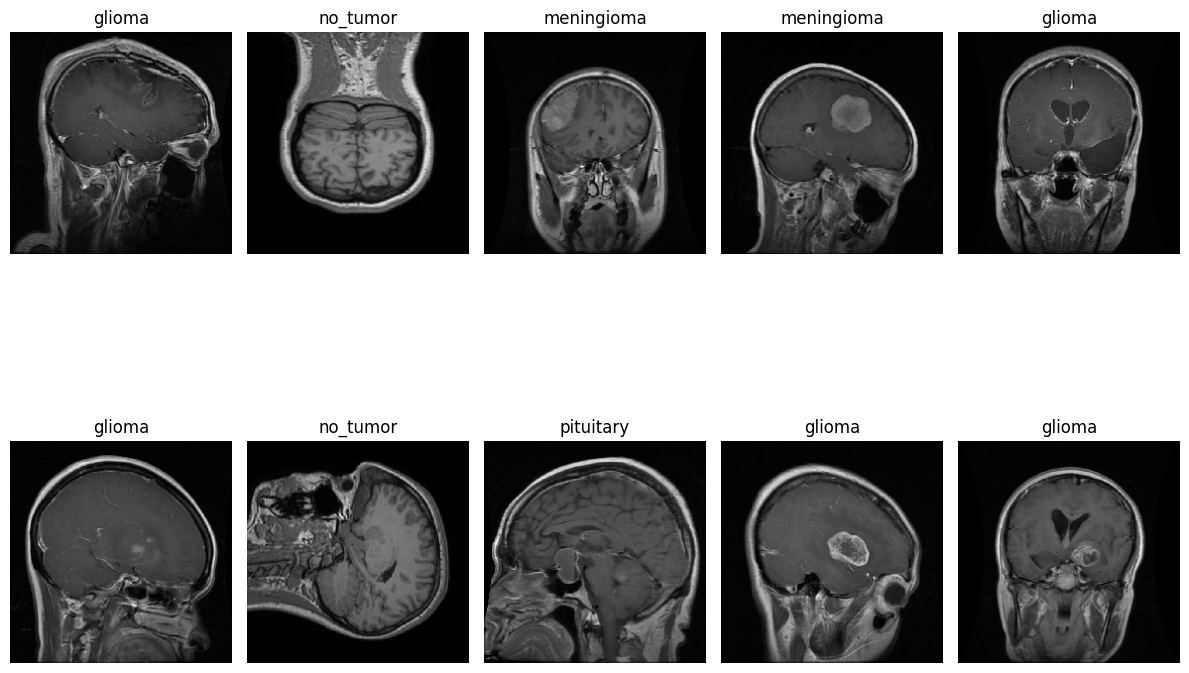

In [10]:
classes = os.listdir(train_dir)

image_paths = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, img_name))
        labels.append(cls)

random_indices = random.sample(range(len(image_paths)), 10)

plt.figure(figsize=(12, 10))

for i, idx in enumerate(random_indices):
    img = load_img(image_paths[idx], target_size=(224, 224))

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(labels[idx])
    plt.axis('off')

plt.tight_layout()
plt.show()

# **Data preprocessing**

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)

Found 2096 images belonging to 4 classes.
Found 398 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


# **MODEL 1 — MobileNetV2**

In [6]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 79s 877ms/step - accuracy: 0.7080 - loss: 0.7177 - val_accuracy: 0.7839 - val_loss: 0.5127
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 465ms/step - accuracy: 0.8316 - loss: 0.4271 - val_accuracy: 0.8442 - val_loss: 0.4159
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 447ms/step - accuracy: 0.8502 - loss: 0.3772 - val_accuracy: 0.8593 - val_loss: 0.3631
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 28s 420ms/step - accuracy: 0.8607 - loss: 0.3604 - val_accuracy: 0.8869 - val_loss: 0.3294
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 443ms/step - accuracy: 0.8969 - loss: 0.2944 - val_accuracy: 0.8668 - val_loss: 0.3558


# **MODEL 2 — ResNet50**

In [11]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

resnet_model = Model(inputs=base_model.input, outputs=predictions)

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,500 (90.98 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [13]:
history_resnet = resnet_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 69s 833ms/step - accuracy: 0.2791 - loss: 1.4284 - val_accuracy: 0.1859 - val_loss: 1.3712
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 455ms/step - accuracy: 0.3025 - loss: 1.3711 - val_accuracy: 0.3894 - val_loss: 1.3571
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 457ms/step - accuracy: 0.3115 - loss: 1.3631 - val_accuracy: 0.4146 - val_loss: 1.3451
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 457ms/step - accuracy: 0.3087 - loss: 1.3620 - val_accuracy: 0.4598 - val_loss: 1.3193
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 31s 462ms/step - accuracy: 0.3507 - loss: 1.3367 - val_accuracy: 0.4221 - val_loss: 1.2873


# **Evaluation Function**

In [14]:
def evaluate_model(model, test_data, class_names):
    predictions = model.predict(test_data)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_data.classes

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

## **MobileNetV2 Results**

=== MobileNetV2 Evaluation ===
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 435ms/step

Classification Report:

              precision    recall  f1-score   support

      glioma       0.90      0.85      0.87       119
  meningioma       0.79      0.71      0.75        96
    no_tumor       0.97      1.00      0.99        74
   pituitary       0.82      0.94      0.88       109

    accuracy                           0.87       398
   macro avg       0.87      0.87      0.87       398
weighted avg       0.87      0.87      0.86       398



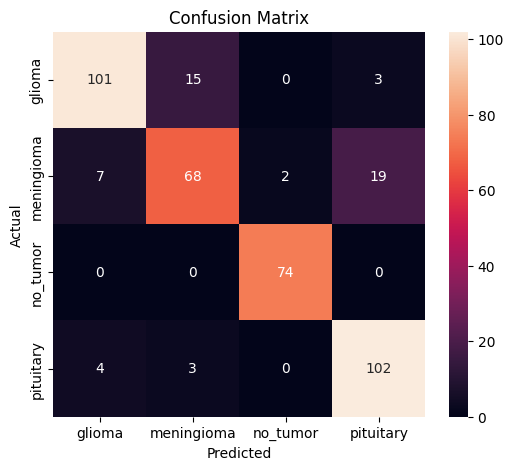

In [15]:
print("=== MobileNetV2 Evaluation ===")
evaluate_model(mobilenet_model, test_data, class_names)

## **ResNet50 Results**

=== ResNet50 Evaluation ===
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 505ms/step

Classification Report:

              precision    recall  f1-score   support

      glioma       0.23      0.04      0.07       119
  meningioma       0.30      0.89      0.45        96
    no_tumor       0.00      0.00      0.00        74
   pituitary       0.80      0.72      0.76       109

    accuracy                           0.42       398
   macro avg       0.33      0.41      0.32       398
weighted avg       0.36      0.42      0.34       398



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


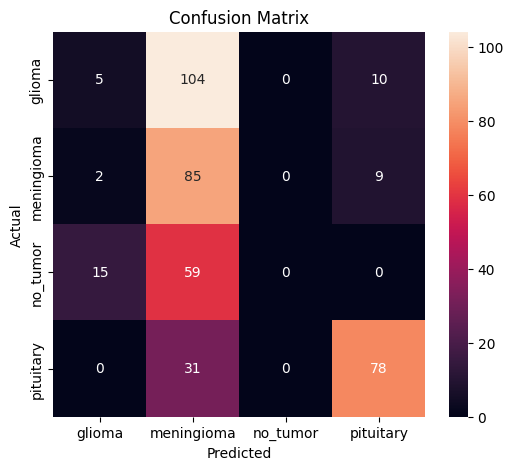

In [16]:
print("=== ResNet50 Evaluation ===")
evaluate_model(resnet_model, test_data, class_names)

## **Accuracy Comparison Plot**

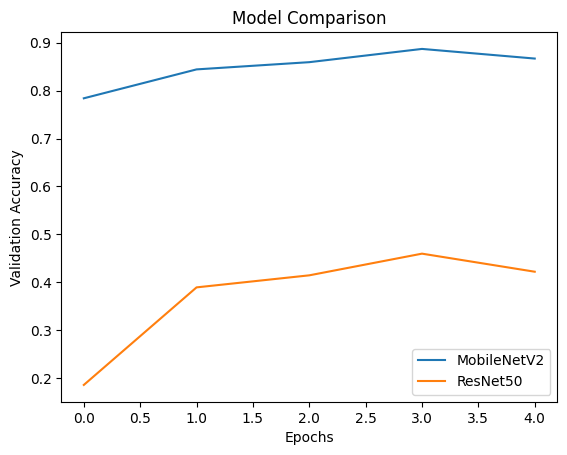

In [17]:
plt.plot(history_mobilenet.history['val_accuracy'], label='MobileNetV2')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet50')
plt.legend()
plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.show()

# **Prediction**

In [23]:
import numpy as np
from tensorflow.keras.preprocessing import image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Class: meningioma
Confidence: 29.94 %


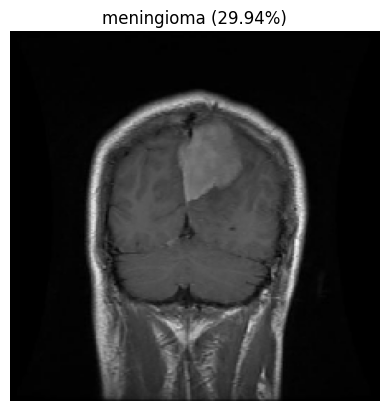

In [24]:
img_path = "/content/dataset/classification_task/test/meningioma/brisc2025_test_00465_me_co_t1.jpg"   # <-- change this

class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)


prediction = resnet_model.predict(img_array)


predicted_index = np.argmax(prediction)
predicted_label = class_names[predicted_index]
confidence = np.max(prediction)


print("Predicted Class:", predicted_label)
print("Confidence:", round(confidence * 100, 2), "%")


plt.imshow(img)
plt.title(f"{predicted_label} ({confidence*100:.2f}%)")
plt.axis('off')
plt.show()